# KiDA / FaSiMo Final Project

Prediction of Driver Sleepiness (KSS) using Physiological Signals and Artificial Neural Networks

Student: Ayah Said

## Project Goal

The objective of this project is to predict the Karolinska Sleepiness Scale (KSS) from physiological signals recorded during driving experiments.

# Imports

In [1]:
from somnus.data import RecordingSession
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import neurokit2 as nk
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


2026-06-28 19:22:39.757836: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-28 19:22:39.794378: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-28 19:22:39.794411: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-28 19:22:39.794442: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-28 19:22:39.801573: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-28 19:22:39.802018: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

# Methodology

The project follows the following pipeline:

1. Explore and understand the KiDA dataset
2. Identify suitable physiological signals
3. Process PPG signals using NeuroKit2
4. Extract dynamic PPG-based features
5. Construct a machine learning dataset
6. Train and evaluate an Artificial Neural Network
7. Compare Chunk, Session, and Patient split strategies
8. Analyze model generalization performance

# 1. Dataset Exploration

Before building machine learning models, it is important to understand the structure of the KiDA dataset. This section loads recording sessions, explores the available recordings, and inspects the physiological signals contained in each session.

The goal is to identify the available sensor channels, sampling frequencies, and signal characteristics that will later be used for feature extraction and sleepiness prediction.

The explored signals include:

- EAR (Eye Aspect Ratio)
- MAR (Mouth Aspect Ratio)
- PPG-related signals
- EDA signals
- Additional physiological measurements
- KSS labels

Understanding the dataset structure is a necessary first step before feature engineering and model development.

In [2]:
sess = RecordingSession.load("Hallo_44052dae-c5a4-41da-85fc-1e695a01968c")

print(sess.recordings.keys())

dict_keys(['recording_11', 'recording_3', 'recording_10', 'recording_6', 'kss_pre', 'recording_9', 'recording_1', 'recording_5', 'recording_0', 'kss_post', 'recording_7', 'recording_2', 'recording_4', 'recording_8'])


In [3]:
rec = sess.recordings["recording_0"]

In [4]:
print(rec.signals.keys())

dict_keys(['present', 'ear_l', 'ear_r', 'mar', 'oxi_sensor', 'resp_sensor', 'eda_sensor', 'ecg_sensor', 'kss_pre', 'kss_post'])


In [5]:
for name in rec.signals.keys():
    sig = rec.signals[name]

    try:
        print(
            name,
            "samples =", sig.get_num_samples(),
            "fs =", sig.avg_fs()
        )
    except:
        print(name)

present samples = 1782 fs = 29.945172423747962
ear_l samples = 1782 fs = 29.945172423747962
ear_r samples = 1782 fs = 29.945172423747962
mar samples = 1782 fs = 29.945172423747962
oxi_sensor samples = 60000 fs = 1000.0
resp_sensor samples = 60000 fs = 1000.0
eda_sensor samples = 60000 fs = 1000.0
ecg_sensor samples = 60000 fs = 1000.0
kss_pre
kss_post


In [6]:
for signal_name in ["oxi_sensor", "resp_sensor", "eda_sensor", "ecg_sensor"]:

    signal = rec.signals[signal_name]
    data = signal.data_np()

    print("\n", signal_name)
    print("Shape:", data.shape)
    print("Min:", data.min())
    print("Max:", data.max())
    print("First 20 values:")
    print(data[:20])


 oxi_sensor
Shape: (60000,)
Min: 0.0
Max: 0.0
First 20 values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

 resp_sensor
Shape: (60000,)
Min: 312.0
Max: 894.0
First 20 values:
[450. 449. 447. 447. 446. 445. 444. 443. 442. 441. 441. 439. 438. 438.
 436. 436. 435. 434. 434. 433.]

 eda_sensor
Shape: (60000,)
Min: 153.0
Max: 833.0
First 20 values:
[442. 443. 442. 442. 443. 442. 443. 442. 442. 443. 442. 443. 442. 442.
 442. 442. 442. 442. 442. 443.]

 ecg_sensor
Shape: (60000,)
Min: 0.0
Max: 2.0
First 20 values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


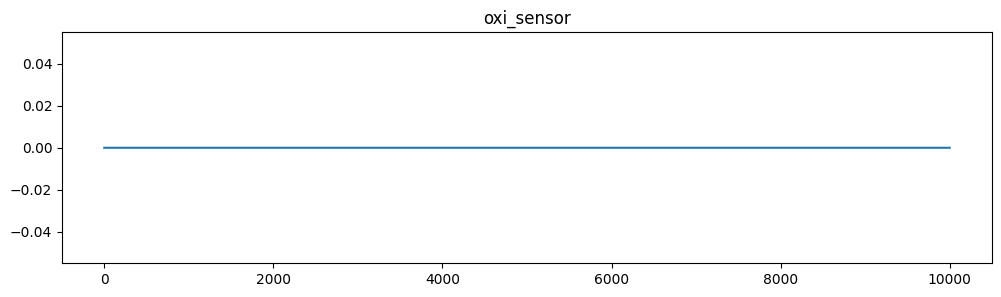

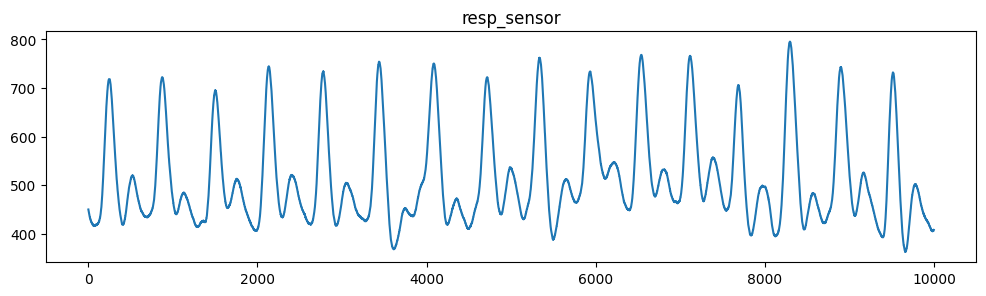

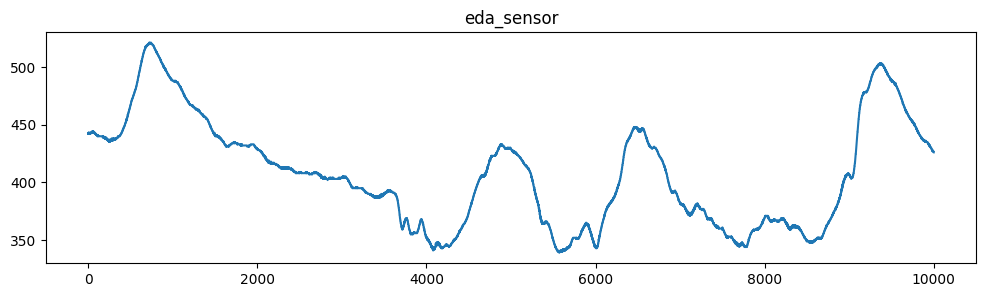

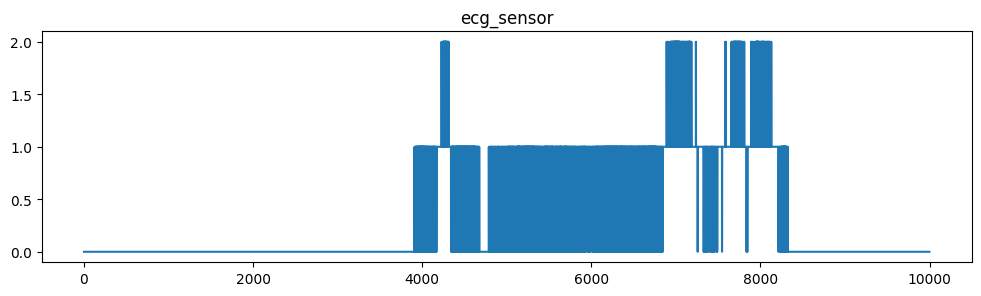

In [7]:
for signal_name in ["oxi_sensor", "resp_sensor", "eda_sensor", "ecg_sensor"]:

    signal = rec.signals[signal_name]
    data = signal.data_np()

    plt.figure(figsize=(12,3))
    plt.plot(data[:10000])
    plt.title(signal_name)
    plt.show()

# KSS Labels

The Karolinska Sleepiness Scale (KSS) is used as the target variable for prediction. Each recording contains a KSS value before (KSS_pre) and after (KSS_post) the driving session.

In this project, KSS_post is used as the prediction target because it reflects the participant's final level of sleepiness after completing the driving task.

In [8]:
print("KSS PRE:")
print(rec.signals["kss_pre"].data_np())

print("KSS POST:")
print(rec.signals["kss_post"].data_np())

KSS PRE:
[4.]
KSS POST:
[4.]


# Selection of the PPG Signal

The available physiological signals were examined to determine which signal could be used for heart-rate-related feature extraction.

The resp_sensor channel was selected as the PPG source because it contained usable pulse-related information and was suitable for further processing.

In [9]:
rec = sess.recordings["recording_0"]

ppg = rec.signals["resp_sensor"]

ppg_data = ppg.data_np()

print(ppg.avg_fs())
print(len(ppg_data))

1000.0
60000


# PPG Signal Processing

The selected PPG signal is processed using NeuroKit2. This step performs signal cleaning, peak detection, heart-rate estimation, and quality assessment.

The processed signal and detected peaks are later used to extract dynamic features for machine learning.

In [10]:
ppg = rec.signals["resp_sensor"].data_np()

signals, info = nk.ppg_process(
    ppg,
    sampling_rate=1000
)

print(signals.head())
print(info.keys())

   PPG_Raw  PPG_Clean  PPG_Rate  PPG_Quality  PPG_Peaks
0    450.0 -35.033473  96.29832     0.993844          0
1    449.0 -35.698765  96.29832     0.993844          0
2    447.0 -36.370233  96.29832     0.993844          0
3    447.0 -37.047266  96.29832     0.993844          0
4    446.0 -37.729252  96.29832     0.993844          0
dict_keys(['method_peaks', 'method_fixpeaks', 'PPG_Peaks', 'sampling_rate'])


# Feature Extraction

To transform raw physiological signals into machine learning inputs, dynamic PPG-based features are extracted from each recording.

The NeuroKit2 library is used to process the signal, detect peaks, estimate heart rate, and compute statistical descriptors. These features form the basis for later KSS prediction using an Artificial Neural Network.

In [11]:
# Extract PPG-based features
def extract_ppg_features(ppg_signal, fs=1000):
    
# Detect peaks and heart rate information
    signals, info = nk.ppg_process(
        ppg_signal,
        sampling_rate=fs
    )

    features = {}

    features["PPG_Rate_Mean"] = signals["PPG_Rate"].mean()

    return features

In [12]:
ppg = rec.signals["resp_sensor"].data_np()

features = extract_ppg_features(ppg)

print(features)

{'PPG_Rate_Mean': 96.31943528407047}


## Peak Detection

After processing the PPG signal, NeuroKit2 detects heartbeat peaks within the cleaned signal.

The detected peaks are visualized below. These peak locations are later used to calculate statistical features such as peak count and peak interval measurements.

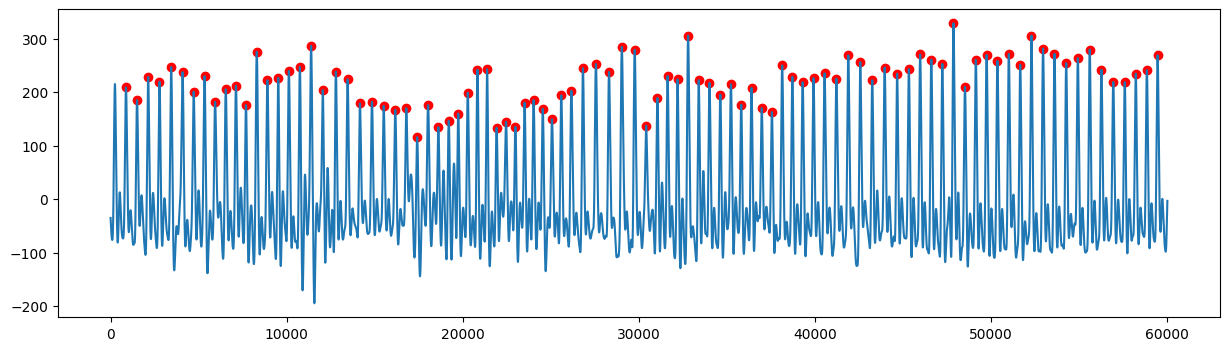

In [13]:
plt.figure(figsize=(15,4))

plt.plot(signals["PPG_Clean"])

plt.scatter(
    info["PPG_Peaks"],
    signals["PPG_Clean"][info["PPG_Peaks"]],
    color="red"
)

plt.show()

In [14]:
all_features = []

# Dataset Construction

After defining the feature extraction pipeline, features are extracted from multiple recording sessions and combined into a single machine learning dataset.

Each recording is processed individually, and the extracted features are stored together with the corresponding KSS labels. The resulting dataset is later used for ANN training and evaluation.

In [15]:
folders = [
    # Hallo
    "Hallo_44052dae-c5a4-41da-85fc-1e695a01968c",
    "Hallo_c2c61492-1ae1-408d-a461-9d7231846f49",
    "Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340",
    "Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537",

    # TJ
    "TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14",
    "TJ_99488596-da89-4220-8f22-ef5dcc0e5103",
    "TJ_a04aea77-1a25-48b6-aff3-ed70909147e5",
    "TJ_a05af087-fa94-43e5-9f20-afce7efde0b1",
    "TJ_4e3992c6-0bc0-4d8e-930c-90af3013af94",
    "TJ_d083ed24-bad0-474a-b2c8-9e675affcbf0",
    "TJ_fa6d9269-838e-4396-a242-1f3a6fc3aff7",

    # BMW
    "bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d",
    "bmw_526d544d-5c55-4313-a97c-756614dc82ab",

    # Bladee
    "bladee_6efb78ee-4336-4647-8b5b-bd57eec605f8",
    "bladee_fe858af8-8bb2-45f8-a359-aa27d44aa235",

    # BumBum
    "BumBum_00309f7e-4d76-467f-812b-bcf00fbe5ad5",
    "BumBum_904822f2-0c4a-47a3-8569-d3682fc4c0d7",
    "BumBum_ba493d0f-78dc-4c67-b46c-66f68cacbb4b",

    # Derwas
    "derwas_3d84b475-3476-431f-9258-33bb067c8025",
    "derwas_86a01446-3347-4132-a649-a4f303dba871",
    "derwas_766e81aa-2244-42a4-8073-df791c98f218",

    # Gab
    "gab_45f9a0cf-cfa2-4087-ba0e-8802959a181f",
    "gab_b762e69f-b0f7-499d-9744-e339ba14a5d5"
]

In [16]:
for folder in folders:

    print("Processing:", folder)

    try:
        sess = RecordingSession.load(folder)
    except Exception as e:
        print("ERROR IN:", folder)
        print(e)
        continue

    for name in sess.recordings.keys():

        if name.startswith("recording_"):

            rec = sess.recordings[name]

            ppg = rec.signals["resp_sensor"].data_np()

            features = extract_ppg_features(ppg)

            features["Participant"] = folder
            features["Recording"] = name

            kss = rec.signals["kss_post"].data_np()[0]
            features["KSS"] = kss

            all_features.append(features)

Processing: Hallo_44052dae-c5a4-41da-85fc-1e695a01968c
Processing: Hallo_c2c61492-1ae1-408d-a461-9d7231846f49
Processing: Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340
Processing: Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537
Processing: TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14
Processing: TJ_99488596-da89-4220-8f22-ef5dcc0e5103
Processing: TJ_a04aea77-1a25-48b6-aff3-ed70909147e5
Processing: TJ_a05af087-fa94-43e5-9f20-afce7efde0b1
Processing: TJ_4e3992c6-0bc0-4d8e-930c-90af3013af94
Processing: TJ_d083ed24-bad0-474a-b2c8-9e675affcbf0
Processing: TJ_fa6d9269-838e-4396-a242-1f3a6fc3aff7
Processing: bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d
Processing: bmw_526d544d-5c55-4313-a97c-756614dc82ab
Processing: bladee_6efb78ee-4336-4647-8b5b-bd57eec605f8
Processing: bladee_fe858af8-8bb2-45f8-a359-aa27d44aa235
Processing: BumBum_00309f7e-4d76-467f-812b-bcf00fbe5ad5
Processing: BumBum_904822f2-0c4a-47a3-8569-d3682fc4c0d7
Processing: BumBum_ba493d0f-78dc-4c67-b46c-66f68cacbb4b
Processing: derwas_3d84b475-34

In [17]:
df = pd.DataFrame(all_features)

print(df.shape)
df.head()

(223, 4)


,PPG_Rate_Mean,Participant,Recording,KSS
0,88.719321,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_11,4.0
1,94.370151,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_3,4.0
2,89.565552,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_10,4.0
3,93.613850,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_6,4.0
4,95.041617,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_9,4.0


In [18]:
print(df["KSS"].value_counts())

KSS
5.0    76
4.0    72
3.0    48
6.0    14
2.0    12
7.0     1
Name: count, dtype: int64


In [19]:
ppg = rec.signals["resp_sensor"].data_np()

signals, info = nk.ppg_process(
    ppg,
    sampling_rate=1000
)

print(signals.columns)

Index(['PPG_Raw', 'PPG_Clean', 'PPG_Rate', 'PPG_Quality', 'PPG_Peaks'], dtype='object')


In [20]:
import neurokit2 as nk
import numpy as np

def extract_ppg_features(ppg_signal, fs=1000):

    signals, info = nk.ppg_process(
        ppg_signal,
        sampling_rate=fs
    )

    peaks = info["PPG_Peaks"]

    peak_intervals = np.diff(peaks)

    features = {}

    # Heart rate features
    features["PPG_Rate_Mean"] = signals["PPG_Rate"].mean()
    features["PPG_Rate_STD"] = signals["PPG_Rate"].std()

    # Signal quality
    features["PPG_Quality_Mean"] = signals["PPG_Quality"].mean()

    # Peak features
    features["Peak_Count"] = len(peaks)

    if len(peak_intervals) > 0:
        features["Peak_Interval_Mean"] = np.mean(peak_intervals)
        features["Peak_Interval_STD"] = np.std(peak_intervals)
    else:
        features["Peak_Interval_Mean"] = 0
        features["Peak_Interval_STD"] = 0

    return features

In [21]:
all_features = []

for folder in folders:

    print("Processing:", folder)

    sess = RecordingSession.load(folder)

    for name in sess.recordings.keys():

        if name.startswith("recording_"):

            rec = sess.recordings[name]
            ppg = rec.signals["resp_sensor"].data_np()

            features = extract_ppg_features(ppg)

            features["Participant"] = folder
            features["Recording"] = name

            kss = rec.signals["kss_post"].data_np()[0]
            features["KSS"] = kss

            all_features.append(features)
        

Processing: Hallo_44052dae-c5a4-41da-85fc-1e695a01968c
Processing: Hallo_c2c61492-1ae1-408d-a461-9d7231846f49
Processing: Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340
Processing: Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537
Processing: TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14
Processing: TJ_99488596-da89-4220-8f22-ef5dcc0e5103
Processing: TJ_a04aea77-1a25-48b6-aff3-ed70909147e5
Processing: TJ_a05af087-fa94-43e5-9f20-afce7efde0b1
Processing: TJ_4e3992c6-0bc0-4d8e-930c-90af3013af94
Processing: TJ_d083ed24-bad0-474a-b2c8-9e675affcbf0
Processing: TJ_fa6d9269-838e-4396-a242-1f3a6fc3aff7
Processing: bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d
Processing: bmw_526d544d-5c55-4313-a97c-756614dc82ab
Processing: bladee_6efb78ee-4336-4647-8b5b-bd57eec605f8
Processing: bladee_fe858af8-8bb2-45f8-a359-aa27d44aa235
Processing: BumBum_00309f7e-4d76-467f-812b-bcf00fbe5ad5
Processing: BumBum_904822f2-0c4a-47a3-8569-d3682fc4c0d7
Processing: BumBum_ba493d0f-78dc-4c67-b46c-66f68cacbb4b
Processing: derwas_3d84b475-34

In [22]:
df = pd.DataFrame(all_features)

print(df.shape)

df.head()

(223, 9)


,PPG_Rate_Mean,PPG_Rate_STD,PPG_Quality_Mean,Peak_Count,Peak_Interval_Mean,Peak_Interval_STD,Participant,Recording,KSS
0,88.719321,4.697577,0.970143,88,676.390805,36.649742,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_11,4.0
1,94.370151,4.908527,0.976295,94,635.806452,34.273178,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_3,4.0
2,89.565552,6.828436,0.960618,89,670.181818,53.221780,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_10,4.0
3,93.613850,6.811475,0.960555,93,642.021739,67.940988,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_6,4.0
4,95.041617,7.401171,0.971714,94,631.236559,52.860823,Hallo_44052dae-c5a4-41da-85fc-1e695a01968c,recording_9,4.0


In [23]:
X = df[[
    "PPG_Rate_Mean",
    "PPG_Rate_STD",
    "PPG_Quality_Mean",
    "Peak_Count",
    "Peak_Interval_Mean",
    "Peak_Interval_STD"
]]

y = df["KSS"]

print(X.shape)
print(y.shape)

(223, 6)
(223,)


# Dataset Splitting

To evaluate the ANN under different conditions, three splitting strategies are used:

1. Chunk Split
2. Session Split
3. Patient Split

Each split is evaluated separately.

# Session Split

In this experiment, entire recording sessions are kept together.

- Training Sessions: recording_0 to recording_8
- Validation Sessions: recording_9 to recording_11

This evaluates whether the model can predict drowsiness in later sessions after learning from earlier sessions.

In [24]:
def split_by_session(df):

    train_sessions = [
        "recording_0",
        "recording_1",
        "recording_2",
        "recording_3",
        "recording_4",
        "recording_5",
        "recording_6",
        "recording_7",
        "recording_8"
    ]

    val_sessions = [
        "recording_9",
        "recording_10",
        "recording_11"
    ]

    train_df = df[df["Recording"].isin(train_sessions)]
    val_df = df[df["Recording"].isin(val_sessions)]

    return train_df, val_df

In [25]:
train_df_session, val_df_session = split_by_session(df)

print("Train:", train_df_session.shape)
print("Validation:", val_df_session.shape)

Train: (166, 9)
Validation: (57, 9)


In [26]:
feature_cols = [
    "PPG_Rate_Mean",
    "PPG_Rate_STD",
    "PPG_Quality_Mean",
    "Peak_Count",
    "Peak_Interval_Mean",
    "Peak_Interval_STD"
]

In [27]:
from sklearn.preprocessing import StandardScaler

X_train = train_df_session[feature_cols]
X_val = val_df_session[feature_cols]

y_train = train_df_session["KSS"]
y_val = val_df_session["KSS"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(X_train_scaled.shape)
print(X_val_scaled.shape)

(166, 6)
(57, 6)


In [28]:
model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(6,)))
model.add(Dense(16, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

2026-06-28 19:23:37.956999: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [29]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    verbose=1
)

Epoch 1/100
6/6 [==============================] - 1s 26ms/step - loss: 14.2354 - mae: 3.5996 - val_loss: 14.1284 - val_mae: 3.5999
Epoch 2/100
6/6 [==============================] - 0s 5ms/step - loss: 13.4324 - mae: 3.4690 - val_loss: 13.3188 - val_mae: 3.4755
Epoch 3/100
6/6 [==============================] - 0s 5ms/step - loss: 12.6031 - mae: 3.3361 - val_loss: 12.5073 - val_mae: 3.3448
Epoch 4/100
6/6 [==============================] - 0s 5ms/step - loss: 11.8046 - mae: 3.2164 - val_loss: 11.7264 - val_mae: 3.2158
Epoch 5/100
6/6 [==============================] - 0s 5ms/step - loss: 11.0422 - mae: 3.1074 - val_loss: 10.9445 - val_mae: 3.1013
Epoch 6/100
6/6 [==============================] - 0s 5ms/step - loss: 10.2671 - mae: 2.9897 - val_loss: 10.1806 - val_mae: 2.9847
Epoch 7/100
6/6 [==============================] - 0s 5ms/step - loss: 9.5210 - mae: 2.8688 - val_loss: 9.4317 - val_mae: 2.8616
Epoch 8/100
6/6 [==============================] - 0s 5ms/step - loss: 8.7974 - mae:

In [30]:
loss, mae = model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Session Split MAE:", mae)

Session Split MAE: 0.7858113050460815


# Patient Split

In this split, participants used for validation are never seen during training.

This represents the most challenging and realistic evaluation scenario because the ANN must generalize to completely unseen subjects.

The training and validation sets are scaled separately using the training statistics before training the ANN.

In [31]:
def split_by_patient(df):

    train_patients = [
        # Hallo
        "Hallo_44052dae-c5a4-41da-85fc-1e695a01968c",
        "Hallo_c2c61492-1ae1-408d-a461-9d7231846f49",
        "Hallo_c3a1c5f0-1c45-4920-8b40-ad579be69340",
        "Hallo_f262e432-0ec1-4a10-a5dd-2bca956da537",

        # TJ
        "TJ_6a0f3fdf-6e9d-4a2e-9dfc-cbc9c87ffa14",
        "TJ_99488596-da89-4220-8f22-ef5dcc0e5103",
        "TJ_a04aea77-1a25-48b6-aff3-ed70909147e5",
        "TJ_a05af087-fa94-43e5-9f20-afce7efde0b1",
        "TJ_4e3992c6-0bc0-4d8e-930c-90af3013af94",
        "TJ_d083ed24-bad0-474a-b2c8-9e675affcbf0",
        "TJ_fa6d9269-838e-4396-a242-1f3a6fc3aff7",

        # BMW
        "bmw_d467cd14-f3fb-4502-a5e2-348c5186ca1d",
        "bmw_526d544d-5c55-4313-a97c-756614dc82ab",

        # Bladee
        "bladee_6efb78ee-4336-4647-8b5b-bd57eec605f8",
        "bladee_fe858af8-8bb2-45f8-a359-aa27d44aa235",
    ]

    val_patients = [
        # BumBum
        "BumBum_00309f7e-4d76-467f-812b-bcf00fbe5ad5",
        "BumBum_904822f2-0c4a-47a3-8569-d3682fc4c0d7",
        "BumBum_ba493d0f-78dc-4c67-b46c-66f68cacbb4b",

        # Derwas
        "derwas_3d84b475-3476-431f-9258-33bb067c8025",
        "derwas_86a01446-3347-4132-a649-a4f303dba871",
        "derwas_766e81aa-2244-42a4-8073-df791c98f218",

        # Gab
        "gab_45f9a0cf-cfa2-4087-ba0e-8802959a181f",
        "gab_b762e69f-b0f7-499d-9744-e339ba14a5d5",
    ]

    train_df = df[df["Participant"].isin(train_patients)]
    val_df = df[df["Participant"].isin(val_patients)]

    return train_df, val_df

In [32]:
train_df_patient, val_df_patient = split_by_patient(df)

print("Train:", train_df_patient.shape)
print("Validation:", val_df_patient.shape)

Train: (180, 9)
Validation: (43, 9)


In [33]:
from sklearn.preprocessing import StandardScaler

X_train = train_df_patient[feature_cols]
X_val = val_df_patient[feature_cols]

y_train = train_df_patient["KSS"]
y_val = val_df_patient["KSS"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(X_train_scaled.shape)
print(X_val_scaled.shape)

(180, 6)
(43, 6)


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(6,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 16)                112       
                                                                 
 dense_4 (Dense)             (None, 16)                272       
                                                                 
 dense_5 (Dense)             (None, 1)                 17        
                                                                 
Total params: 401 (1.57 KB)
Trainable params: 401 (1.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [35]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    verbose=1
)

Epoch 1/100
6/6 [==============================] - 0s 19ms/step - loss: 13.9220 - mae: 3.6180 - val_loss: 27.1609 - val_mae: 5.1154
Epoch 2/100
6/6 [==============================] - 0s 5ms/step - loss: 13.2362 - mae: 3.5153 - val_loss: 25.3299 - val_mae: 4.9408
Epoch 3/100
6/6 [==============================] - 0s 5ms/step - loss: 12.5693 - mae: 3.4137 - val_loss: 23.6192 - val_mae: 4.7699
Epoch 4/100
6/6 [==============================] - 0s 5ms/step - loss: 11.8997 - mae: 3.3084 - val_loss: 21.9479 - val_mae: 4.5942
Epoch 5/100
6/6 [==============================] - 0s 5ms/step - loss: 11.2433 - mae: 3.2018 - val_loss: 20.3446 - val_mae: 4.4170
Epoch 6/100
6/6 [==============================] - 0s 5ms/step - loss: 10.6223 - mae: 3.0956 - val_loss: 18.7894 - val_mae: 4.2363
Epoch 7/100
6/6 [==============================] - 0s 5ms/step - loss: 9.9978 - mae: 2.9828 - val_loss: 17.2672 - val_mae: 4.0500
Epoch 8/100
6/6 [==============================] - 0s 5ms/step - loss: 9.3792 - mae

In [36]:
loss, mae = model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Patient Split MAE:", mae)

Patient Split MAE: 1.8696805238723755


# Chunk Split

In this split, individual chunks are randomly divided into training and validation sets.

Chunks from the same participant and recording may appear in both sets.

This represents the easiest evaluation scenario because the ANN may see very similar samples during training and validation.

In [37]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    train_size=0.8,
    shuffle=True,
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (178, 9)
Validation: (45, 9)


In [38]:
from sklearn.preprocessing import StandardScaler

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]

y_train = train_df["KSS"]
y_val = val_df["KSS"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(X_train_scaled.shape)
print(X_val_scaled.shape)

(178, 6)
(45, 6)


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(6,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 16)                112       
                                                                 
 dense_7 (Dense)             (None, 16)                272       
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 401 (1.57 KB)
Trainable params: 401 (1.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [40]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    verbose=1
)

Epoch 1/100
6/6 [==============================] - 0s 19ms/step - loss: 16.9882 - mae: 3.9760 - val_loss: 15.4105 - val_mae: 3.8096
Epoch 2/100
6/6 [==============================] - 0s 5ms/step - loss: 15.8867 - mae: 3.8358 - val_loss: 14.4519 - val_mae: 3.6833
Epoch 3/100
6/6 [==============================] - 0s 5ms/step - loss: 14.8958 - mae: 3.6994 - val_loss: 13.5397 - val_mae: 3.5586
Epoch 4/100
6/6 [==============================] - 0s 5ms/step - loss: 13.9220 - mae: 3.5679 - val_loss: 12.6906 - val_mae: 3.4373
Epoch 5/100
6/6 [==============================] - 0s 5ms/step - loss: 13.0672 - mae: 3.4406 - val_loss: 11.8764 - val_mae: 3.3155
Epoch 6/100
6/6 [==============================] - 0s 5ms/step - loss: 12.2203 - mae: 3.3097 - val_loss: 11.0998 - val_mae: 3.1949
Epoch 7/100
6/6 [==============================] - 0s 5ms/step - loss: 11.4357 - mae: 3.1891 - val_loss: 10.3362 - val_mae: 3.0714
Epoch 8/100
6/6 [==============================] - 0s 5ms/step - loss: 10.6620 - m

In [41]:
loss, mae = model.evaluate(
    X_val_scaled,
    y_val,
    verbose=0
)

print("Chunk Split MAE:", mae)

Chunk Split MAE: 0.7384832501411438


In [42]:
print(df["Recording"].unique())

['recording_11' 'recording_3' 'recording_10' 'recording_6' 'recording_9'
 'recording_1' 'recording_5' 'recording_0' 'recording_7' 'recording_2'
 'recording_4' 'recording_8']


# Conclusion

The ANN was evaluated using three different dataset splitting strategies.

Results:

- Chunk Split MAE: 0.738
- Session Split MAE: 0.782
- Patient Split MAE: 1.869

The Chunk Split achieved the lowest error because similar samples from the same participants may appear in both training and validation. Session Split is more challenging since complete recording sessions are separated. Patient Split is the most difficult and realistic evaluation because the model must generalize to completely unseen participants.